In [1]:
import torch
from diffusers.utils import make_image_grid
from IPython.display import display, clear_output
from PIL import Image
from slideredit.pipelines import SliderEditFluxKontextPipeline
from itertools import product

from transformers import CLIPTextModel, T5EncoderModel, BitsAndBytesConfig
from diffusers import AutoencoderKL, FlowMatchEulerDiscreteScheduler
from diffusers.models import FluxTransformer2DModel
from slideredit.pipelines import LoRAAdapterType
from slideredit.pipelines.flux_kontext import (
    create_stlora_tokens_mask_and_scale,
    flux_kontext_find_substring_token_indices,
    set_stlora_scale,
    stlora_token_mask_ctx
)
import os

/tmp/SliderEdit_Inference/venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from huggingface_hub import login

# Bypasses the text box prompt by loading the token directly from your cluster file
with open("/cs/student/msc/ml/2025/eoikonom/.hf_token", "r") as f:
    login(token=f.read().strip())

## GSTLoRA

In [4]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

MODEL_ID = "black-forest-labs/FLUX.1-Kontext-dev"

# Load heavy text encoders straight to GPU in bfloat16
clip_text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", torch_dtype=torch.bfloat16).to("cuda")
t5_text_encoder = T5EncoderModel.from_pretrained(MODEL_ID, subfolder="text_encoder_2", torch_dtype=torch.bfloat16).to("cuda")
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae").to("cuda", dtype=torch.bfloat16)

transformer = FluxTransformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=quantization_config,
    device_map={"": "cuda"}
)

print("🔌 Assembling the SliderEdit Pipeline...")
pipe = SliderEditFluxKontextPipeline.from_pretrained(
    MODEL_ID,
    vae=vae,
    text_encoder=clip_text_encoder,
    text_encoder_2=t5_text_encoder,
    transformer=transformer,
    torch_dtype=torch.bfloat16
)

# pipe = SliderEditFluxKontextPipeline.from_pretrained(
#     "black-forest-labs/FLUX.1-Kontext-dev", 
#     quantization_config=pipeline_quant_config, 
#     torch_dtype=torch.bfloat16
#     ).to("cuda")
pipe.load_gstlora("./checkpoints/gstlora_iter500.safetensors")
clear_output()
print("Pipeline with GSTLoRA loaded successfully!")

Pipeline with GSTLoRA loaded successfully!


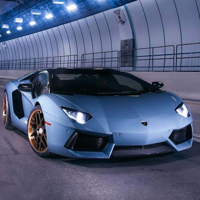

Edit prompt: make the car red


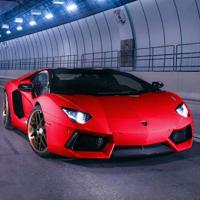

In [4]:
img = Image.open("./datasets/test_images/blue-car.jpg").convert("RGB")
edit_prompt = "make the car red"
alpha_values = [1.2]# [-2, -1, -0.5, 0, 0.5, 1, 2]

# for quantized models, we need to set the adapter type to LoRAAdapterType.GSTLORA
pipe.loaded_adapter = LoRAAdapterType.GSTLORA

output_dir = "./outputs/gstlora"
os.makedirs(output_dir, exist_ok=True)

outputs = []
with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    for alpha in alpha_values:
        output_image = pipe(
            image=img,  
            prompt=edit_prompt,
            generator=torch.Generator().manual_seed(0),
            slider_alpha=alpha,
        ).images[0]

        # Save dynamically to /tmp/SliderEdit_Inference/outputs/
        safe_prompt = edit_prompt.replace(" ", "_")[:20]
        save_path = os.path.join(output_dir, f"{safe_prompt}_alpha_{alpha}b.png")
        output_image.save(save_path)

        outputs.append(output_image)

clear_output()
display(img.resize((200, 200)))
print(f"Edit prompt: {edit_prompt}")
make_image_grid([x.resize((200, 200)) for x in outputs], rows=1, cols=len(outputs))

## STLoRA

In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

MODEL_ID = "black-forest-labs/FLUX.1-Kontext-dev"

# Load heavy text encoders straight to GPU in bfloat16
clip_text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", dtype=torch.bfloat16).to("cuda")
t5_text_encoder = T5EncoderModel.from_pretrained(MODEL_ID, subfolder="text_encoder_2", dtype=torch.bfloat16).to("cuda")
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae").to("cuda", dtype=torch.bfloat16)

transformer = FluxTransformer2DModel.from_pretrained(
    MODEL_ID,
    subfolder="transformer",
    quantization_config=quantization_config,
    device_map={"": "cuda"}
)

print("🔌 Assembling the SliderEdit Pipeline...")
pipe = SliderEditFluxKontextPipeline.from_pretrained(
    MODEL_ID,
    vae=vae,
    text_encoder=clip_text_encoder,
    text_encoder_2=t5_text_encoder,
    transformer=transformer,
    torch_dtype=torch.bfloat16
)

# pipe.load_stlora("./checkpoints/stlora_iter1200.pt", lora_rank=16, lora_dropout=0.0)
pipe.load_stlora("./checkpoints/stlora_iter1200.safetensors", lora_rank=16, lora_dropout=0.0)
clear_output()
print("Pipeline with STLoRA loaded successfully!")

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 240.82it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 80.00 MiB. GPU 0 has a total capacity of 23.54 GiB of which 13.31 MiB is free. Process 23885 has 22.14 GiB memory in use. Including non-PyTorch memory, this process has 1.36 GiB memory in use. Of the allocated memory 989.37 MiB is allocated by PyTorch, and 14.63 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

: 

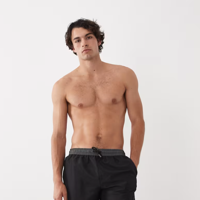

Edit prompt: add tattoos to the person and make the person's skin darker


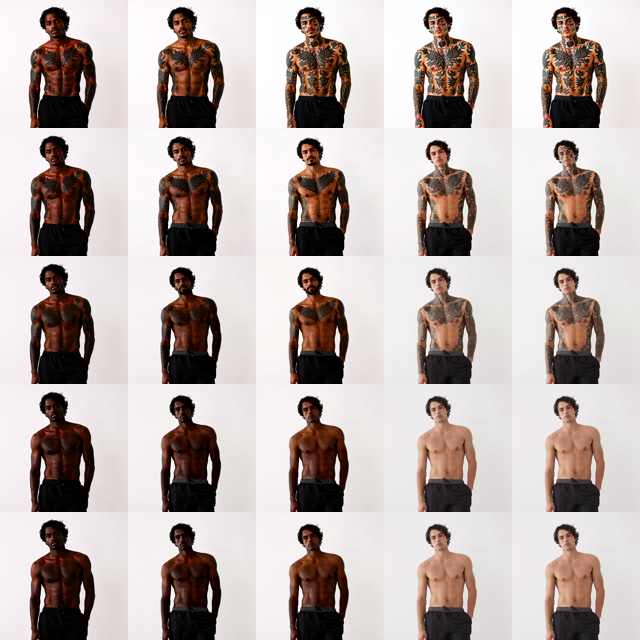

In [ ]:
img = Image.open("./datasets/test_images/swimtrunks-black.png").convert("RGB")
edit_prompt = "add tattoos to the person and make the person's skin lighter"
edit_subprompts = ["add tattoos to the person", "make the person's skin lighter"]
alpha_list = [-2, -1, 0, 1, 2]
alpha_values_list = product(alpha_list, repeat=2)

# for quantized models, we need to set the adapter type to LoRAAdapterType.GSTLORA
pipe.loaded_adapter = LoRAAdapterType.STLORA

output_dir = "./outputs/stlora"
os.makedirs(output_dir, exist_ok=True)

outputs = []
with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
    for alpha_values in alpha_values_list:
        output_image = pipe(
            image=img,
            prompt=edit_prompt,
            generator=torch.Generator().manual_seed(0),
            subprompts_list=edit_subprompts,
            slider_alpha_list=alpha_values,
        ).images[0]

        filename_parts = []
        for subprompt, val in zip(edit_subprompts, alpha_values):
            clean_sub = subprompt.replace(" ", "_")
            filename_parts.append(f"{clean_sub}_{val:.1f}")
        
        # Join them together into one long, explicit filename
        filename = "_".join(filename_parts) + ".png"
        save_path = os.path.join(output_dir, filename)
        output_image.save(save_path)

        outputs.append(output_image)

clear_output()
display(img.resize((200, 200)))
print(f"Edit prompt: {edit_prompt}")
make_image_grid([x.resize((128, 128)) for x in outputs], rows=len(alpha_list), cols=len(alpha_list))